<a href="https://colab.research.google.com/github/Swaraj-sj2000/Image_processing/blob/main/image_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import tensorflow as tf
from datasets import load_dataset

In [23]:
dataset=load_dataset("blanchon/EuroSAT_RGB")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


In [24]:
len(dataset['train'])

16200

In [25]:
print(dataset['train'].features['label'])

ClassLabel(names=['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake'])


In [26]:
train_ds = dataset["train"]
test_ds  = dataset["test"]
val_ds   = dataset["validation"]

print(type(train_ds))
print(train_ds.features)

<class 'datasets.arrow_dataset.Dataset'>
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']), 'filename': Value('string')}


(64, 64, 3)


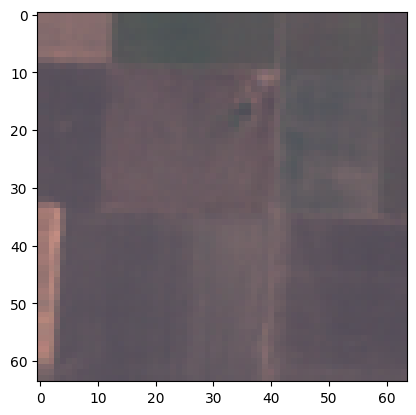

In [27]:
import matplotlib.pyplot as plt
import numpy as np
sample=train_ds[0]['image']
print(np.asarray(sample).shape)
plt.imshow(np.asarray(sample))
plt.show()

In [28]:
sample=next(iter(train_ds))
sample_image=sample['image']
print(sample_image.size)
print(sample_image.mode)
print(sample['label'])
print(sample['filename'])
print(sample)

(64, 64)
RGB
0
AnnualCrop_1.tif
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x7B513C5FAAB0>, 'label': 0, 'filename': 'AnnualCrop_1.tif'}


In [29]:
print(np.asarray(sample_image))

[[[136 109 109]
  [136 109 109]
  [135 108 108]
  ...
  [ 92  83  92]
  [ 94  83  93]
  [ 93  83  92]]

 [[136 109 109]
  [136 109 109]
  [135 108 108]
  ...
  [ 92  83  92]
  [ 94  83  93]
  [ 93  83  92]]

 [[131 106 107]
  [131 106 107]
  [131 107 109]
  ...
  [ 93  84  92]
  [ 93  83  91]
  [ 93  83  92]]

 ...

 [[129 105 108]
  [129 105 108]
  [128 104 106]
  ...
  [ 93  83  93]
  [ 92  82  92]
  [ 92  83  92]]

 [[120 101 104]
  [120 101 104]
  [117 100 104]
  ...
  [ 95  85  94]
  [ 95  85  94]
  [ 98  86  96]]

 [[111  97 100]
  [111  97 100]
  [109  94 100]
  ...
  [ 95  86  93]
  [ 96  86  94]
  [ 99  87  95]]]


In [30]:
import numpy as np
IMAGE_SIZE=(64,64)

def hf_generator(split):
  for sample in split:
    image=np.asarray(sample['image'],dtype=np.uint8)
    label=sample['label']

    yield {'images':image,'labels':label}


def preprocess(x):
    image = tf.cast(x['images'], tf.float32)
    label = x['labels']
    return {'images':image, 'labels':label}

In [31]:
BUFFER_SIZE=2000
BATCH_SIZE=32

train_tf=tf.data.Dataset.from_generator(
    lambda: hf_generator(train_ds),
    output_signature={
        'images':tf.TensorSpec(shape=(64,64,3),dtype=tf.float32),
        'labels':tf.TensorSpec(shape=(),dtype=tf.int64)
    }
).map(preprocess,num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [32]:
test_tf=tf.data.Dataset.from_generator(
    lambda: hf_generator(test_ds),
    output_signature={
        'images':tf.TensorSpec(shape=(64,64,3),dtype=tf.float32),
        'labels':tf.TensorSpec(shape=(),dtype=tf.int64)
    }
)

val_tf=tf.data.Dataset.from_generator(
    lambda: hf_generator(val_ds),
    output_signature={
        'images':tf.TensorSpec(shape=(64,64,3),dtype=tf.float32),
        'labels':tf.TensorSpec(shape=(),dtype=tf.int64)
    }
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [33]:
sample=next(iter(train_tf))
print(sample)

{'images': <tf.Tensor: shape=(32, 64, 64, 3), dtype=float32, numpy=
array([[[[106.,  94.,  97.],
         [106.,  94.,  97.],
         [119., 100., 103.],
         ...,
         [118., 120., 116.],
         [117., 119., 116.],
         [119., 119., 115.]],

        [[106.,  94.,  97.],
         [106.,  94.,  97.],
         [119., 100., 103.],
         ...,
         [118., 120., 116.],
         [117., 119., 116.],
         [119., 119., 115.]],

        [[102.,  92.,  97.],
         [102.,  92.,  97.],
         [107.,  94.,  99.],
         ...,
         [128., 123., 119.],
         [121., 121., 117.],
         [122., 120., 117.]],

        ...,

        [[232., 195., 180.],
         [232., 195., 180.],
         [237., 198., 182.],
         ...,
         [ 47.,  82.,  83.],
         [ 48.,  82.,  84.],
         [ 49.,  81.,  84.]],

        [[206., 169., 160.],
         [206., 169., 160.],
         [231., 195., 185.],
         ...,
         [ 48.,  82.,  83.],
         [ 48.,  82.,  83.],

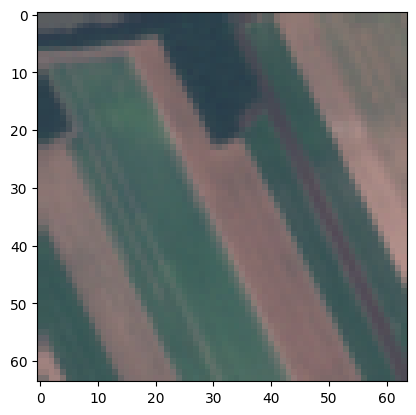

In [34]:
import matplotlib.pyplot as plt
sample = next(iter(train_tf))
img = sample['images'][0]

plt.imshow(img.numpy()/255.0)
plt.show()

In [35]:
cat_classes=train_ds.features['label'].names
num_classes = len(cat_classes)
print(cat_classes,"\n",num_classes)

['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake'] 
 10


In [36]:
def count(state,item):
  label=item['labels']
  state[label]+=1
  return state

class_counts=train_tf.unbatch().reduce(
    tf.zeros(num_classes,tf.int32),
    lambda state,x:state+tf.math.bincount(tf.cast(x['labels'],tf.int32),minlength=num_classes)
)
print("Class counts:", class_counts)
print("Total samples:", tf.reduce_sum(class_counts))

Class counts: tf.Tensor([1791 1787 1799 1505 1492 1195 1481 1863 1460 1827], shape=(10,), dtype=int32)
Total samples: tf.Tensor(16200, shape=(), dtype=int32)


In [37]:
IMG_SIZE = (224, 224)

def preprocess(sample, mode="cnn"):
    image = sample["images"]
    label = sample["labels"]

    image = tf.cast(image, tf.float32)

    if mode == "cnn":
        # [0,255] → [0,1]
        image = image / 255.0

    elif mode == "resnet":
        # expects [0,255]
        image = tf.keras.applications.resnet50.preprocess_input(image)

    elif mode == "efficientnet":
        # scales internally to [-1,1]
        image = tf.keras.applications.efficientnet.preprocess_input(image)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return {
        "images": image,
        "labels": label
    }

In [38]:
def create_pipeline(split, mode="cnn", shuffle=False):

    ds = tf.data.Dataset.from_generator(
        lambda: hf_generator(split),
        output_signature={
            "images": tf.TensorSpec(shape=(64,64,3), dtype=tf.uint8),
            "labels": tf.TensorSpec(shape=(), dtype=tf.int64)
        }
    )

    ds = ds.map(
        lambda x: preprocess(x, mode),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(2000)

    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [39]:
train_tf = create_pipeline(train_ds, mode="resnet", shuffle=True)
val_tf   = create_pipeline(val_ds, mode="resnet")
test_tf  = create_pipeline(test_ds, mode="resnet")
sample = next(iter(train_tf))

print(sample["images"].shape)
print(sample["images"].dtype)
print(tf.reduce_min(sample["images"]), tf.reduce_max(sample["images"]))

(32, 64, 64, 3)
<dtype: 'float32'>
tf.Tensor(-103.68, shape=(), dtype=float32) tf.Tensor(131.32, shape=(), dtype=float32)


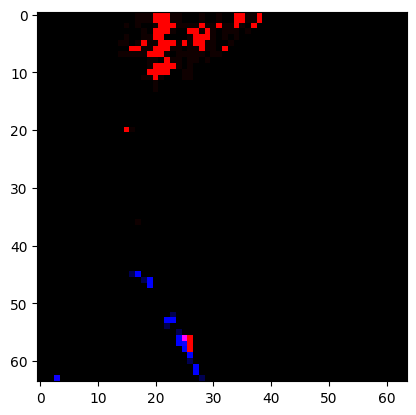

In [40]:
b1=next(iter(train_tf))
plt.imshow(b1['images'][0],)
plt.show()

In [41]:
import os
import json
base_path = "tf_eurosat/eurosat_v1"

os.makedirs(f"{base_path}/train", exist_ok=True)
os.makedirs(f"{base_path}/val", exist_ok=True)
os.makedirs(f"{base_path}/test", exist_ok=True)

metadata_dict={
  "dataset_name": "eurosat_rgb",
  "version": "v1",
  "num_classes": num_classes,
  "image_size": [64, 64, 3],
  "train_samples": 16200,
  "val_samples": 5400,
  "test_samples": 5400,
  "num_shards": {
    "train": 10,
    "val": 2,
    "test": 2
  },
  "created_at": "2026-05-05"
}

label_names=dataset['train'].features['label'].names
label_dict = {str(i): name for i, name in enumerate(label_names)}

feature_dict={
  "features": {
    "images": "bytes",
    "labels": "int64"
  }}

with open(f"{base_path}/metadata.json", "w") as f:
    json.dump(metadata_dict, f, indent=4)

with open(f"{base_path}/label_map.json", "w") as f:
    json.dump(label_dict, f, indent=4)

with open(f"{base_path}/schema.json", "w") as f:
    json.dump(feature_dict, f, indent=4)


In [42]:
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(image, label):
    image_bytes = tf.io.encode_png(image).numpy()

    feature = {
        "images": _bytes_feature(image_bytes),
        "labels": _int64_feature(label),
    }

    example = tf.train.Example(
        features=tf.train.Features(feature=feature)
    )

    return example.SerializeToString()

In [43]:
NUM_SHARDS = 10
base_path = "tf_eurosat/eurosat_v1"

writers = [
    tf.io.TFRecordWriter(f"{base_path}/train/train_{i:03d}.tfrecord")
    for i in range(NUM_SHARDS)
]

for idx, sample in enumerate(train_tf.unbatch()):

    image = np.asarray(sample["images"], dtype=np.uint8)
    label = int(sample["labels"])

    serialized = serialize_example(image, label)

    writers[idx % NUM_SHARDS].write(serialized)

    if not idx%100:
      print(f"processed {idx}th sample")

for w in writers:
    w.close()
print("train_done")


processed 0th sample
processed 100th sample
processed 200th sample
processed 300th sample
processed 400th sample
processed 500th sample
processed 600th sample
processed 700th sample
processed 800th sample
processed 900th sample
processed 1000th sample
processed 1100th sample
processed 1200th sample
processed 1300th sample
processed 1400th sample
processed 1500th sample
processed 1600th sample
processed 1700th sample
processed 1800th sample
processed 1900th sample
processed 2000th sample
processed 2100th sample
processed 2200th sample
processed 2300th sample
processed 2400th sample
processed 2500th sample
processed 2600th sample
processed 2700th sample
processed 2800th sample
processed 2900th sample
processed 3000th sample
processed 3100th sample
processed 3200th sample
processed 3300th sample
processed 3400th sample
processed 3500th sample
processed 3600th sample
processed 3700th sample
processed 3800th sample
processed 3900th sample
processed 4000th sample
processed 4100th sample
proc

In [44]:
NUM_TEST_SHARDS = 2

test_writers = [
    tf.io.TFRecordWriter(f"{base_path}/test/test_{i:03d}.tfrecord")
    for i in range(NUM_TEST_SHARDS)
]

for idx, sample in enumerate(test_tf.unbatch()):

    image = np.asarray(sample["images"], dtype=np.uint8)
    label = int(sample["labels"])

    serialized = serialize_example(image, label)

    test_writers[idx % NUM_TEST_SHARDS].write(serialized)
    if not idx%100:
      print(f"processed {idx}th sample")


for w in test_writers:
    w.close()

print("test_done")

processed 0th sample
processed 100th sample
processed 200th sample
processed 300th sample
processed 400th sample
processed 500th sample
processed 600th sample
processed 700th sample
processed 800th sample
processed 900th sample
processed 1000th sample
processed 1100th sample
processed 1200th sample
processed 1300th sample
processed 1400th sample
processed 1500th sample
processed 1600th sample
processed 1700th sample
processed 1800th sample
processed 1900th sample
processed 2000th sample
processed 2100th sample
processed 2200th sample
processed 2300th sample
processed 2400th sample
processed 2500th sample
processed 2600th sample
processed 2700th sample
processed 2800th sample
processed 2900th sample
processed 3000th sample
processed 3100th sample
processed 3200th sample
processed 3300th sample
processed 3400th sample
processed 3500th sample
processed 3600th sample
processed 3700th sample
processed 3800th sample
processed 3900th sample
processed 4000th sample
processed 4100th sample
proc

In [45]:
NUM_VAL_SHARDS = 2

val_writers = [
    tf.io.TFRecordWriter(f"{base_path}/val/val_{i:03d}.tfrecord")
    for i in range(NUM_VAL_SHARDS)
]

for idx, sample in enumerate(val_tf.unbatch()):

    image = np.asarray(sample["images"], dtype=np.uint8)
    label = int(sample["labels"])

    serialized = serialize_example(image, label)

    val_writers[idx % NUM_VAL_SHARDS].write(serialized)

    if not idx%100:
      print(f"processed {idx}th sample")

print("val_done")
for w in val_writers:
    w.close()

processed 0th sample
processed 100th sample
processed 200th sample
processed 300th sample
processed 400th sample
processed 500th sample
processed 600th sample
processed 700th sample
processed 800th sample
processed 900th sample
processed 1000th sample
processed 1100th sample
processed 1200th sample
processed 1300th sample
processed 1400th sample
processed 1500th sample
processed 1600th sample
processed 1700th sample
processed 1800th sample
processed 1900th sample
processed 2000th sample
processed 2100th sample
processed 2200th sample
processed 2300th sample
processed 2400th sample
processed 2500th sample
processed 2600th sample
processed 2700th sample
processed 2800th sample
processed 2900th sample
processed 3000th sample
processed 3100th sample
processed 3200th sample
processed 3300th sample
processed 3400th sample
processed 3500th sample
processed 3600th sample
processed 3700th sample
processed 3800th sample
processed 3900th sample
processed 4000th sample
processed 4100th sample
proc

In [46]:
print(os.listdir("."))

['.config', 'tf_eurosat', 'sample_data']


In [47]:
'''
import shutil
shutil.rmtree("tf_eurosat")

'''

'\nimport shutil\nshutil.rmtree("tf_eurosat")\n\n'

reading /sharding

In [48]:
train_files=tf.data.Dataset.list_files("/content/tf_eurosat/eurosat_v1/train/*.tfrecord")
for item in train_files:
  print(item.numpy())


b'/content/tf_eurosat/eurosat_v1/train/train_003.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_001.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_008.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_000.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_007.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_006.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_004.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_005.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_002.tfrecord'
b'/content/tf_eurosat/eurosat_v1/train/train_009.tfrecord'


In [49]:
test_files=tf.data.Dataset.list_files("/content/tf_eurosat/eurosat_v1/test/*.tfrecord")
val_files=tf.data.Dataset.list_files("/content/tf_eurosat/eurosat_v1/val/*.tfrecord")


In [50]:
feature_description={
    'images':tf.io.FixedLenFeature([],dtype=tf.string),
    'labels':tf.io.FixedLenFeature([],dtype=tf.int64)
}

In [56]:
def parse_example(example):
  parsed=tf.io.parse_single_example(example,feature_description)
  image=tf.io.decode_png(parsed['images'],channels=3)
  label=parsed['labels']

  return {'images':image,'labels':label}

In [57]:
train_dsr=train_files.interleave(
    lambda x:tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE)

test_dsr=test_files.interleave(
    lambda x:tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE)

val_dsr=val_files.interleave(
    lambda x:tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE)


In [60]:
sample=next(iter(train_dsr))
img=sample['images']
lbl=sample['labels']
print(img)
print(lbl)

tf.Tensor(
[[[239 215 193]
  [239 215 193]
  [244 223 210]
  ...
  [250 228 236]
  [249 228 237]
  [249 230 238]]

 [[239 215 193]
  [239 215 193]
  [244 223 210]
  ...
  [250 228 236]
  [249 228 237]
  [249 230 238]]

 [[246 225 213]
  [246 225 213]
  [251 231 227]
  ...
  [247 228 236]
  [248 229 236]
  [249 230 235]]

 ...

 [[  4 243 255]
  [  4 243 255]
  [  4 245   3]
  ...
  [233 208 186]
  [233 209 182]
  [233 208 182]]

 [[  5 244   2]
  [  5 244   2]
  [  3 245   2]
  ...
  [233 208 184]
  [232 209 184]
  [234 209 182]]

 [[  5 244   1]
  [  5 244   1]
  [  5 245   0]
  ...
  [233 208 185]
  [233 207 184]
  [233 210 184]]], shape=(64, 64, 3), dtype=uint8)
tf.Tensor(0, shape=(), dtype=int64)


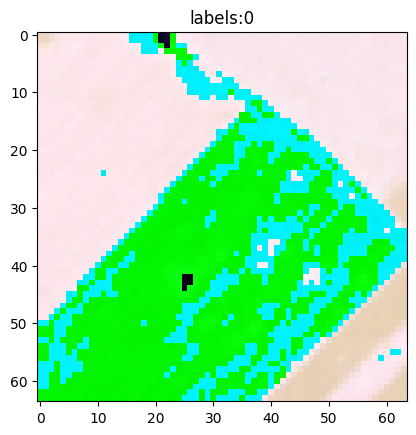

In [61]:
import matplotlib.pyplot as plt
plt.imshow(np.asarray(img,dtype=np.uint8)/255.0)
plt.title(f"labels:{lbl}")
plt.show()

In [55]:
print(img.shape)

(64, 64, 3)
